In [1]:
import numpy as np
import string
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import astropy.units as u
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord
from matplotlib.patches import Ellipse
from astropy.stats import mad_std
import matplotlib as mpl
from photutils.profiles import RadialProfile
from scipy.ndimage import map_coordinates

In [2]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Set Definitions

In [3]:
def plot_contours(data_array, color, sigma_m0, sigma_min, sigma_max, sigma_step):

    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma_m0 * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=[
            ra_offsets.min(), ra_offsets.max(),
            dec_offsets.min(), dec_offsets.max()
        ],
    )


def beam(beam_minor, beam_major, beam_pa, beam_position):
    # Set beam location
    beam_x = ra_offsets.min() + beam_position + 1
    beam_y = dec_offsets.min() + beam_position

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )

def line_profile(image, center, angle_deg, max_radius_pix, width=1, npoints=200):

    xc, yc = center
    r = np.linspace(-max_radius_pix, max_radius_pix, npoints)

    theta = np.deg2rad(angle_deg)

    # unit vector along slit
    dx = np.cos(theta)
    dy = np.sin(theta)

    # perpendicular direction
    px = -np.sin(theta)
    py = np.cos(theta)

    profiles = []

    offsets = np.arange(-(width//2), width//2 + 1)

    for off in offsets:

        x = xc + r*dx + off*px
        y = yc + r*dy + off*py

        coords = np.vstack((y, x))
        profile = map_coordinates(image, coords, order=1)

        profiles.append(profile)

    profile_avg = np.nanmean(profiles, axis=0)

    # central line coordinates (for plotting)
    x_line = xc + r*dx
    y_line = yc + r*dy

    return r, profile_avg, x_line, y_line


# Find Beam Values

In [4]:
# Load the FITS file
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_Combine_pbcor_masked.fits'
fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_cont_robust0.5.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_Continuum_natural_thres0.4mJy.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/CARMA/CARMA_NRO_Orion_12CO_HOPS-164_cut.fits'

hdu = fits.open(fits_file)[0]  # Open the primary HDU
wcs = WCS(hdu.header)          # Extract WCS projection

header = hdu.header

# Extract beam parameters and convert degrees to arcminutes
bmaj = (header.get('BMAJ', 0) * u.deg).to(u.arcmin)
bmin = (header.get('BMIN', 0) * u.deg).to(u.arcmin)
bpa  = header.get('BPA', 0)         # position angle in degrees

print(f"Beam major axis: {bmaj:.3f}'")
print(f"Beam minor axis: {bmin:.3f}'")
print(f"Beam position angle: {bpa:.2f}°")

Beam major axis: 0.021 arcmin'
Beam minor axis: 0.016 arcmin'
Beam position angle: 84.20°


# Read Cube and Find RMS Value

In [5]:
cube_12CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_12CO.allow_huge_operations = True 
cube_12CO = cube_12CO.to(u.K).with_spectral_unit(u.km/u.s)

# Set Radial Parameters

In [6]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
# marker_coord = SkyCoord("5h37m00.540s", "-6d37m10.75s", frame='icrs')

# Actual Coordinates checked in CARMA
marker_coord = SkyCoord("5h37m00.42s", "-6d37m10.9s", frame='icrs')
x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_12CO.wcs.celestial)
print(x_marker, y_marker)

# Pick center
xycen = (x_marker, y_marker)

# Choose to where you want the plot (pixels per step)
pixel_scale = 0.17  # arcsec per pixel

229.04485915454842 220.41830172852295


# 12CO Moment 0 Channel Maps

/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/

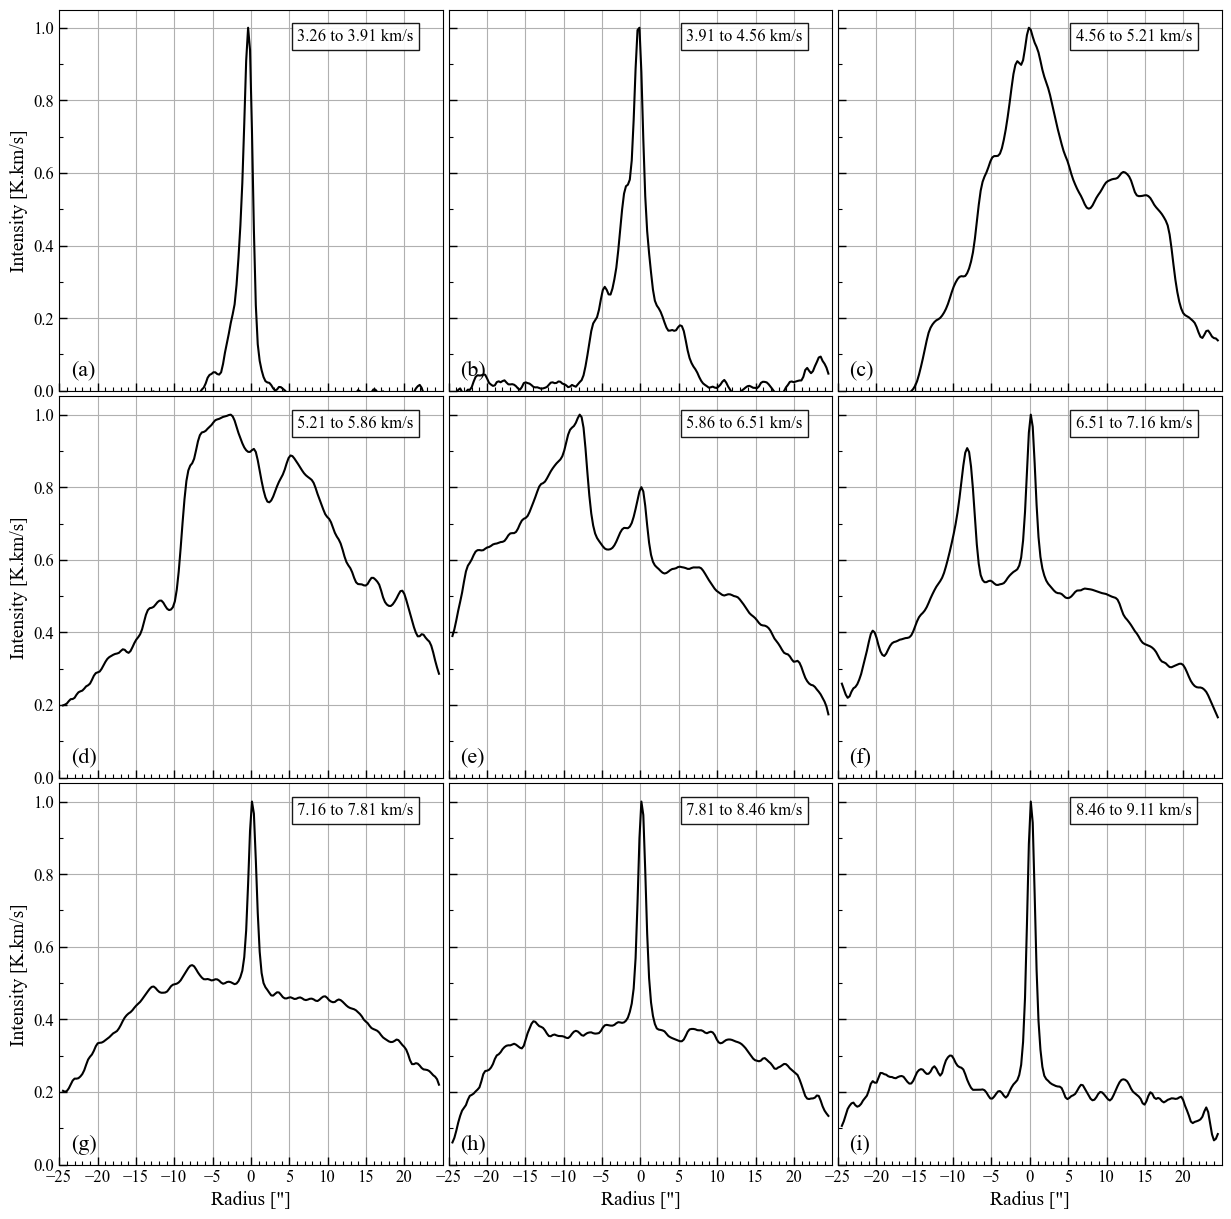

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(3.26, 9.24, 0.65)

for idx, v in enumerate(vel_bins[:-1]): 
    row = idx // 3  # Calculate the row index 
    col = idx % 3   # Calculate the column index
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_12CO = cube_12CO.spectral_slab(v_start, v_end)
    moment0_12CO = slab_12CO.moment0().value

    # Make the line profile
    max_radius = 25 / pixel_scale
    r, profile, _, _ = line_profile(moment0_12CO, xycen, 270, max_radius, width=7)
    radius_arcsec_12CO = r * pixel_scale
    profile_12CO = profile / np.nanmax(profile)

    # Plot the line intensity profile
    ax.plot(radius_arcsec_12CO, profile_12CO, '-', color='black', label=r'$^{12}$CO')
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.03, 0.08, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    ax.set_xlim(-25, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-25, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-25, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_12CO_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_12CO_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# Read Cube and Find RMS Value

In [9]:
# cube_N2Dp =SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits')
# cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

cube_N2Dp = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits')
cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

In [11]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
# marker_coord = SkyCoord("5h37m00.540s", "-6d37m10.75s", frame='icrs')

# Actual Coordinates checked in CARMA
marker_coord = SkyCoord("5h37m00.42s", "-6d37m10.9s", frame='icrs')
x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_N2Dp.wcs.celestial)
print(x_marker, y_marker)

# Pick center
xycen_N2Dp = (x_marker, y_marker)

# Choose to where you want the plot (pixels per step)
pixel_scale_N2Dp = 0.34  # large_sm_reb
# pixel_scale_N2Dp = 0.17 # large_combine

114.27242957727421 109.95915086426147


# N2D+ Channel Maps

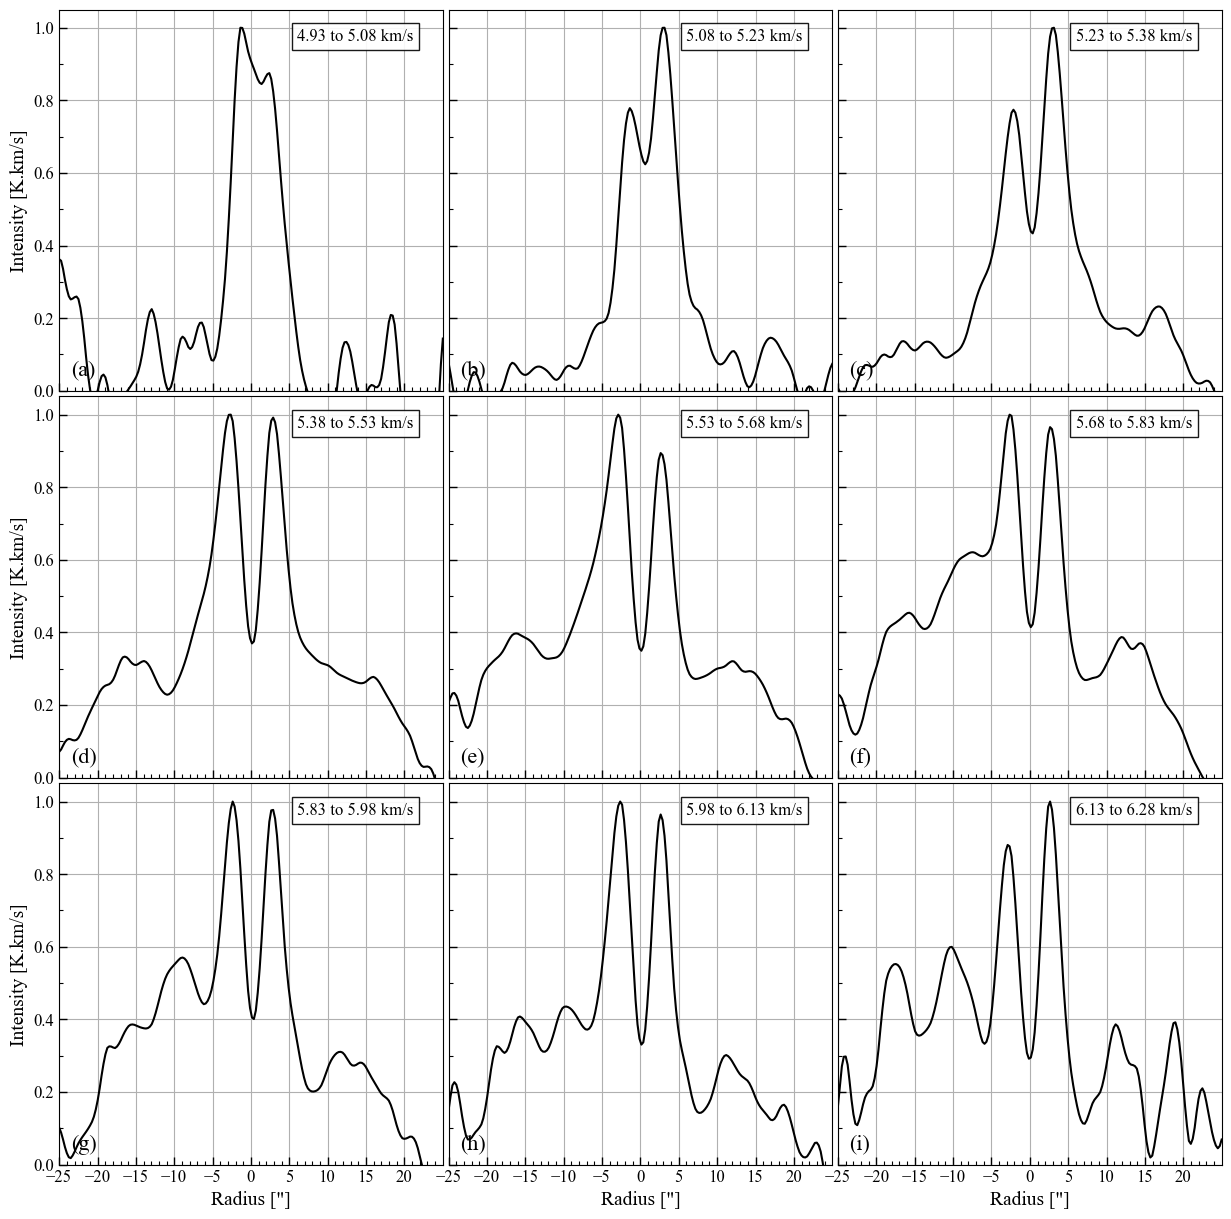

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(4.93, 6.36, 0.15)

for idx, v in enumerate(vel_bins[:-1]):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_N2Dp = cube_N2Dp.spectral_slab(v_start, v_end)
    moment0_N2Dp = slab_N2Dp.moment0().value
    
    # Make the line profile
    max_radius = 25 / pixel_scale_N2Dp
    r, profile, _, _ = line_profile(moment0_N2Dp, xycen_N2Dp, 270, max_radius, width=7)
    radius_arcsec_N2Dp = r * pixel_scale_N2Dp
    profile_N2Dp = profile / np.nanmax(profile)

    # Plot the line intensity profile
    ax.plot(radius_arcsec_N2Dp, profile_N2Dp, '-', color='black', label=r'N$_{2}$D$^{+}') 
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.03, 0.08, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    ax.set_xlim(-25, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-25, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-25, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_N2Dp_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# Comparison

/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/

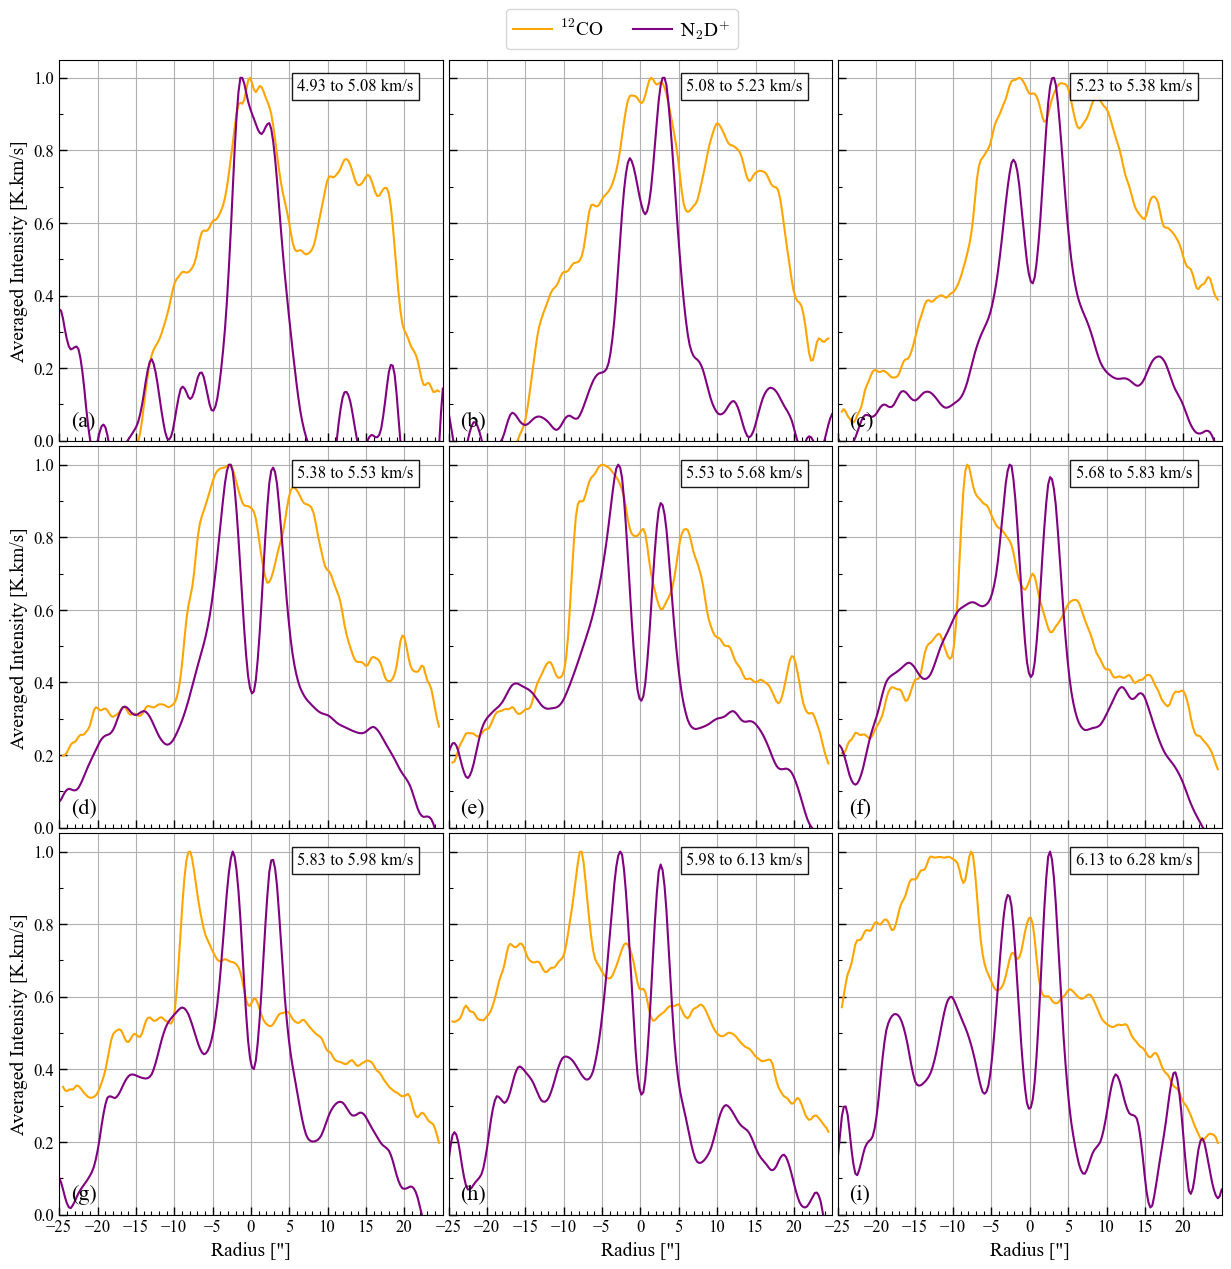

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(4.93, 6.36, 0.15)

for idx, v in enumerate(vel_bins[:-1]):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_12CO = cube_12CO.spectral_slab(v_start, v_end)
    moment0_12CO = slab_12CO.moment0().value

    slab_N2Dp = cube_N2Dp.spectral_slab(v_start, v_end)
    moment0_N2Dp = slab_N2Dp.moment0().value

    # Make the line profile
    max_radius = 25 / pixel_scale
    r, profile, _, _ = line_profile(moment0_12CO, xycen, 270, max_radius, width=7)
    radius_arcsec_12CO = r * pixel_scale
    profile_12CO = profile / np.nanmax(profile)
    
    # Make the line profile
    max_radius = 25 / pixel_scale_N2Dp
    r, profile, _, _ = line_profile(moment0_N2Dp, xycen_N2Dp, 270, max_radius, width=7)
    radius_arcsec_N2Dp = r * pixel_scale_N2Dp
    profile_N2Dp = profile / np.nanmax(profile)

    # Plot the line intensity profile
    ax.plot(radius_arcsec_12CO, profile_12CO, '-', color='orange', label=r'$^{12}$CO')
    ax.plot(radius_arcsec_N2Dp, profile_N2Dp, '-', color='purple', label=r'N$_{2}$D$^{+}$') 

    label = string.ascii_lowercase[idx] 
    ax.text(0.03, 0.08, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    ax.set_xlim(-25, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-25, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-25, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Averaged Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), fontsize=14, ncol=2, columnspacing=1.5, handletextpad=0.4)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_12CO_over_N2Dp_channel_map_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_12CO_over_N2Dp_channel_map_comparison.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# All Channels

/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/dlr31z6s4_x3gkpts6_vzhq80000gn/T/ipykernel_69547/1876471550.py:65: RuntimeWarning: Mean of empty slice
  profile_avg = np.nanmean(profiles, axis=0)
/var/folders/zb/

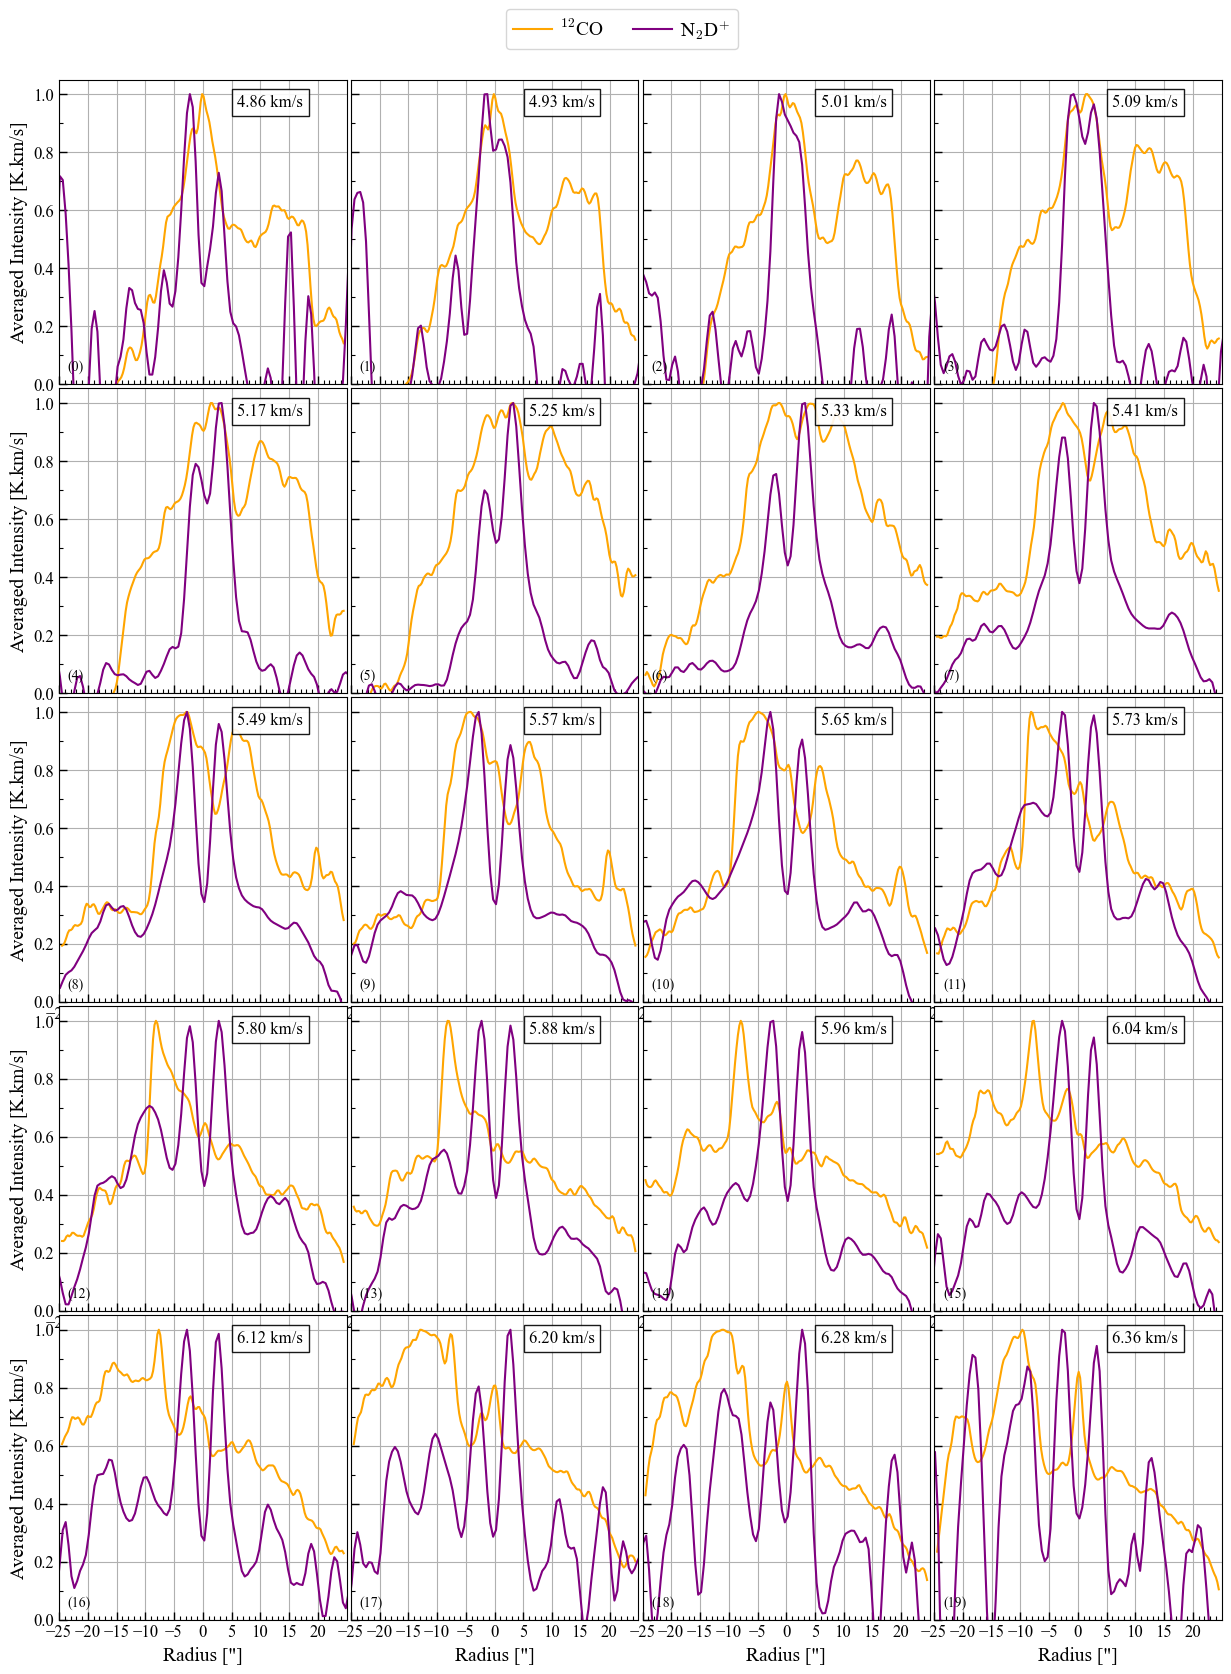

In [15]:
fig, axes = plt.subplots(5, 4, figsize=(15, 20))

for idx, i in enumerate(range(119, 139, 1)):  
    row = idx // 4  # Calculate the row index (0 to 4)
    col = idx % 4   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    # Get velocity for the current slice
    velocity = cube_N2Dp.spectral_axis[i].to(u.km / u.s).value

    # Find channel
    target_velocity = velocity * u.km / u.s
    diff = np.abs(cube_12CO.spectral_axis - target_velocity)
    channel = np.argmin(diff)

    # Make the line profile
    max_radius = 25 / pixel_scale
    r, profile, _, _ = line_profile(cube_12CO[channel], xycen, 270, max_radius, width=7)
    radius_arcsec_12CO = r * pixel_scale
    profile_12CO = profile / np.nanmax(profile)
    
    # Make the line profile
    max_radius = 25 / pixel_scale
    r, profile, _, _ = line_profile(cube_N2Dp[i], xycen_N2Dp, 270, max_radius, width=7)
    radius_arcsec_N2Dp = r * pixel_scale_N2Dp
    profile_N2Dp = profile / np.nanmax(profile)

    # Plot the line intensity profile
    ax.plot(radius_arcsec_12CO, profile_12CO, '-', color='orange', label=r'$^{12}$CO')
    ax.plot(radius_arcsec_N2Dp, profile_N2Dp, '-', color='purple', label=r'N$_{2}$D$^{+}$') 

    ax.text(0.03, 0.08, f"({idx})",
        transform=ax.transAxes,
        fontsize=10, va='top', ha='left')

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    ax.set_xlim(-25, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-25, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-25, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Averaged Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), fontsize=14, ncol=2, columnspacing=1.5, handletextpad=0.4)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_12CO_over_N2Dp_channel_map_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_12CO_over_N2Dp_channel_map_comparison.png", format="png", dpi=300, bbox_inches="tight")

plt.show()